<a href="https://colab.research.google.com/github/BelenUrdangarin/Integrador-Urdangarin---Olivera/blob/main/Pre_entrega_4(Urdangarin_Olivera).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Pre-entrega 4: Aprendizaje no Supervizado

Se aplicarán técnicas de agrupamiento no supervisado, como K-Means con el fin de identificar patrones naturales entre países según sus variables ambientales representativas. Este análisis busca explorar si existen grupos en los datos que puedan corresponder con distintos niveles de impacto o progreso, sin necesidad de etiquetas predefinidas.

Consignas:

- Desarrollo de un modelo de aprendizaje no supervisado (clustering).
- Análisis exploratorio.
- Aplicación de algoritmo.
- Justificación de decisiones tomadas.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [44]:
clim_pais_fil = pd.read_csv("https://raw.githubusercontent.com/BelenUrdangarin/Integrador-Urdangarin---Olivera/refs/heads/main/clim_pais_filtrado.csv", sep=',',on_bad_lines='skip',na_values="..") #Importo los datos
prod_ren_fil = pd.read_csv("https://raw.githubusercontent.com/BelenUrdangarin/Integrador-Urdangarin---Olivera/refs/heads/main/prod_ren_fil.csv", sep=',',on_bad_lines='skip',na_values="..") #Importo los datos
clim_pais_fil.shape


(50488, 15)

In [45]:
print(clim_pais_fil.columns)  # Muestra las columnas disponibles

Index(['country', 'latitude', 'longitude', 'last_updated',
       'temperature_celsius', 'condition_text', 'wind_mph', 'pressure_mb',
       'precip_mm', 'cloud', 'uv_index', 'air_quality_Carbon_Monoxide',
       'air_quality_PM2.5', 'air_quality_PM10', 'continent'],
      dtype='object')


Previo a la utilización de un algoritmo de aprendizaje no supervisado se deben normalizar los datos para que su media sea 0 y la desviación estandar igual a 1, lo que provoca que todas las variables se encuentren en la misma escala.
Escalar es importante porque muchos algoritmos de clustering usan distancias para agrupar muestras, entonces si una variables tiene un escala mucho mas grande que otra, ésta dominará en distancia.

In [46]:
Clim_sc = clim_pais_fil.drop(columns=["country","continent","last_updated","condition_text"])
#Para escalar los datos tenemos que sacar aquellos que no contengan variables numericas
#Pero las almacenaremos para un analisis posterior.
print(Clim_sc)

       latitude  longitude  temperature_celsius  wind_mph  pressure_mb  \
0       34.5200    69.1800                 26.6       8.3       1012.0   
1       41.3300    19.8200                 19.0       6.9       1012.0   
2       42.5000     1.5200                  6.3       7.4       1007.0   
3       17.1200   -61.8500                 26.0       5.6       1013.0   
4      -34.5900   -58.6700                  8.0       2.2       1014.0   
...         ...        ...                  ...       ...          ...   
50483   41.3167    69.2500                 30.1      13.2       1019.0   
50484  -17.7333   168.3167                 26.2      13.4       1013.0   
50485   15.3547    44.2067                 26.9       9.8       1012.0   
50486  -15.4167    28.2833                 27.7       6.0       1014.0   
50487  -17.8178    31.0447                 24.7       7.4       1015.0   

       precip_mm  cloud  uv_index  air_quality_Carbon_Monoxide  \
0           0.00     30       7.0            

In [47]:
scal = StandardScaler()
clim_scal = scal.fit_transform(Clim_sc) #dataset original
print(clim_scal)

[[ 0.59053006  0.78772162  0.44856323 ... -0.13699398 -0.35448372
  -0.1051929 ]
 [ 0.85846129  0.03448194 -0.40445749 ... -1.03828354 -0.67255501
  -0.27414106]
 [ 0.90449353 -0.24477832 -1.82990001 ... -1.29116334 -0.68998358
  -0.28169565]
 ...
 [-0.16350555  0.40662598  0.4822351  ... -0.47146535  0.08558753
   0.55576526]
 [-1.37416916  0.16363294  0.57202676 ...  0.86804114 -0.16429451
  -0.19385634]
 [-1.46863754  0.20577224  0.23530805 ...  0.52816636 -0.18041593
  -0.19766798]]


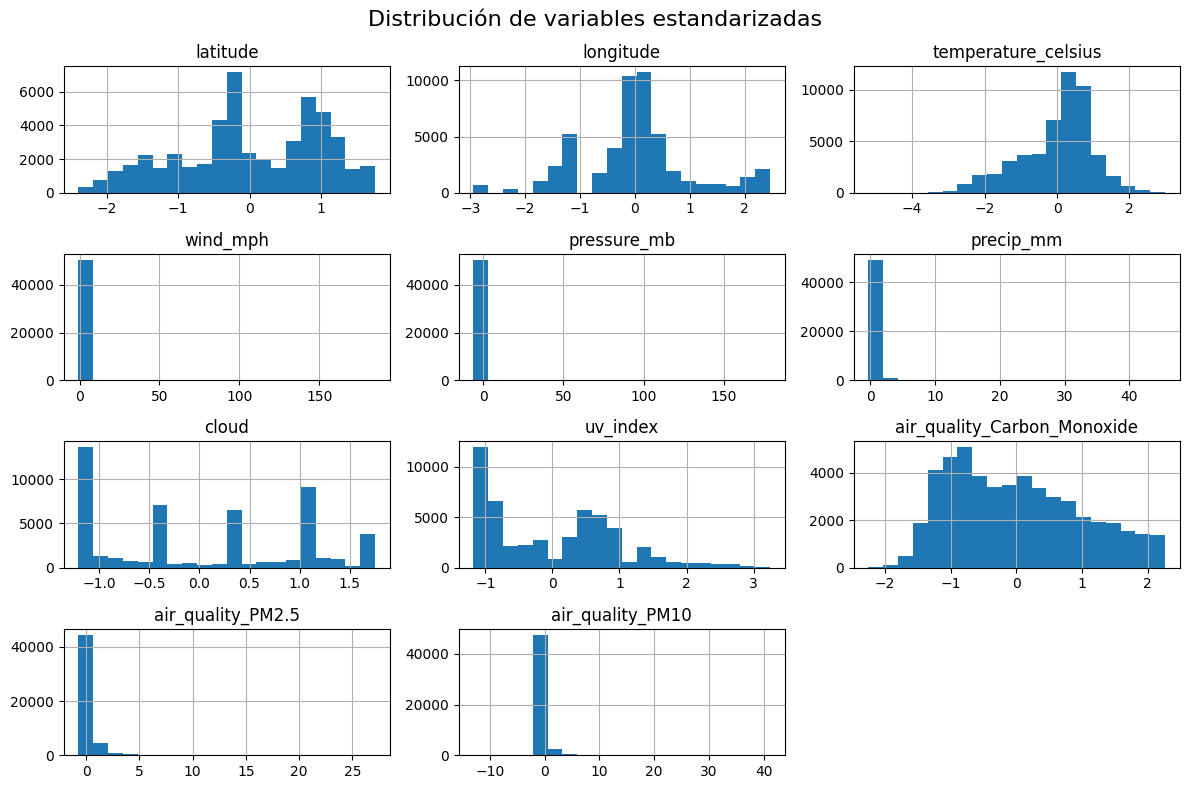

In [48]:
clim_print = pd.DataFrame(clim_scal, columns=Clim_sc.columns)  # Usamos las columnas originales

clim_print.hist(figsize=(12, 8), bins=20)
plt.suptitle('Distribución de variables estandarizadas', fontsize=16)
plt.tight_layout()
plt.show()

En la imagen se puede ver como para muchas variables como latitud, longitud, temperatura, calidad de aire e indice UV el resultado quedo bien centrado, con formas simetricas y distribución estandar. El resto de las variables se encuentran concentrados en valores bajos, lo que indica que la distribución original era sesgada. Se debera tener en cuenta esto en algoritmos sensibles a la forma de la distribución.

###K-means
Luego de escalar los datos, utilizaremos K-means para agrupar las variables. Como en la entrega anterior se buscó agruparlos en tres grupos, en esta entrega se utilizará el mismo principio para comparar los resultados obtenidos.

In [49]:
Cmeans = KMeans(n_clusters=3, random_state=42)
clusters = Cmeans.fit_predict(clim_scal)
#Asignamos cada país a un cluster segun los patrones que el algoritmo encuentre
clim_pais_fil['Cluster'] = clusters #Sumamos las columnas de clusters al DF original


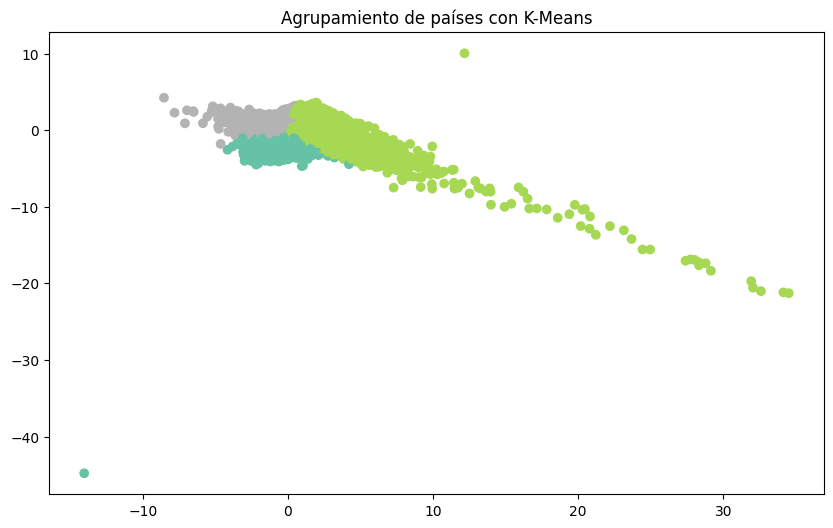

In [50]:
#Graficamos los clusters
#PCA es una reducción dimensional que encuentra las componentes principales que captura la mayor varianza en la data.
#PCA toma todas las variables y busca las direcciones que más varían en el conjunto de datos.
pca = PCA(n_components=2) #Dos dimensiones para que se pueda graficar como un scatter plot.
X_pca = pca.fit_transform(clim_scal) #Acá se aplica PCA al df ya escalado

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set2')
plt.title('Agrupamiento de países con K-Means')
#Graficamos los clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(clim_scal)


En el grafico anterior podemos vislumbrar que la mayoria de los paises tienen caracteristicas similares en las direcciones principales evaluadas lo que genera que los clusters se encuentren posicionados juntos, con muy pocos paises que se encuentrar alejados de los grupos principales.

In [51]:
clim_pais_fil.groupby('Cluster').mean(numeric_only=True)

,latitude,longitude,temperature_celsius,wind_mph,pressure_mb,precip_mm,cloud,uv_index,air_quality_Carbon_Monoxide,air_quality_PM2.5,air_quality_PM10
Cluster,,,,,,,,,,,
0,41.561081,4.456585,11.839116,8.297330,1017.337321,0.071286,44.394295,1.721666,352.498965,16.905087,24.508301
1,17.629381,20.339545,28.779432,9.552287,1012.541885,0.016411,16.364889,7.579608,285.009757,24.265756,81.071019
2,4.724883,24.625316,24.372855,9.249928,1012.461079,0.323020,63.223453,2.812850,246.834478,8.244537,14.552560


- Cluster 0 combinación de templado y contaminado:
Zonas de clima fresco con contaminación de aire elevada, típicas de áreas industriales o urbanas de latitudes medias-altas.

- Cluster 1 combinación de clima cálido y contaminado:
Regiones de clima cálido extremo y seco, con alta radiación solar y niveles críticos de contaminación urbana.

- Cluster 2 combinación de clima tropical y no tan contaminado:
Áreas tropicales con cobertura nubosa y lluvias regulares, lo que ayuda a mantener niveles de contaminación y radiación UV más bajos.

In [52]:
#El siguiente codigo se centra en identificar y analizar los paises que se encuentran mas
#Alejados de los centros de los clusters, se los considera outliers

centroids = Cmeans.cluster_centers_ #Toma los centros de los clusters ya calculados

distances = np.linalg.norm(clim_scal - centroids[clusters], axis=1)
#Se calcula la distancia de cada punto de datos al centroide

clim_pais_fil['dist_to_centroid'] = distances #Crea una columna de distancias en el df original
#para almacenar las distancias calculadas

#Aca se identifican los dos paises mas alejados de los centroides
outliers = clim_pais_fil.nlargest(2, 'dist_to_centroid')
print(outliers[['country','Cluster','dist_to_centroid']])
#Se imprime una tabla con el nombre del pais, el cluster al que esta asignado y la distancia al centroide


        country  Cluster  dist_to_centroid
6390    Burundi        1        185.043937
38128  Honduras        0        178.398496


In [53]:
clim_pais_fil.groupby('Cluster')['country'].count()

,country
Cluster,
0,13708
1,18718
2,18062


In [54]:
#Traemos de nuevolas caracteristicas de los clusters para compararlos con los outliers.
clim_pais_fil.groupby('Cluster').mean(numeric_only=True)


,latitude,longitude,temperature_celsius,wind_mph,pressure_mb,precip_mm,cloud,uv_index,air_quality_Carbon_Monoxide,air_quality_PM2.5,air_quality_PM10,dist_to_centroid
Cluster,,,,,,,,,,,,
0,41.561081,4.456585,11.839116,8.297330,1017.337321,0.071286,44.394295,1.721666,352.498965,16.905087,24.508301,2.156244
1,17.629381,20.339545,28.779432,9.552287,1012.541885,0.016411,16.364889,7.579608,285.009757,24.265756,81.071019,2.369458
2,4.724883,24.625316,24.372855,9.249928,1012.461079,0.323020,63.223453,2.812850,246.834478,8.244537,14.552560,2.560467


In [55]:
# Obtenemos las características de Burundi y Honduras
burundicarac = clim_pais_fil[clim_pais_fil['country'] == 'Burundi'].mean(numeric_only=True)
hondurascarac = clim_pais_fil[clim_pais_fil['country'] == 'Honduras'].mean(numeric_only=True)

print("Características de Burundi:")
display(burundicarac)

print("\nCaracterísticas de Honduras:")
display(hondurascarac)

Características de Burundi:


,0
latitude,-3.378535
longitude,29.360000
temperature_celsius,27.526519
wind_mph,19.075691
pressure_mb,1013.303867
precip_mm,0.198895
cloud,38.950276
uv_index,8.353039
air_quality_Carbon_Monoxide,391.237845
air_quality_PM2.5,14.972486



Características de Honduras:


,0
latitude,14.100000
longitude,-87.217979
temperature_celsius,18.593772
wind_mph,4.249827
pressure_mb,1024.567474
precip_mm,0.062145
cloud,62.332180
uv_index,1.512111
air_quality_Carbon_Monoxide,351.538581
air_quality_PM2.5,7.483304


Burundi fue asignado al grupo caracterizado por alta temperatura, baja nubosidad, baja precipitación y altos niveles de radiación UV y contaminación. Si bien comparte varios de estos rasgos, sus condiciones particulares lo alejan del centro del cluster:

 - Radiación UV extrema (8.35), superior al promedio del grupo.

 - Contaminación por monóxido de carbono muy elevada (391 ppm).

 - Velocidad del viento significativamente superior (19.1 mph).

 - Mayor cobertura nubosa (39 %).

Estas variables intensificadas lo convierten en un caso ambientalmente extremo, reforzando su pertenencia al cluster pero diferenciándose de los patrones comunes por la superposición de múltiples factores severos.

Por otro lado, Honduras se agrupa en un cluster de países templados, de latitudes altas, con baja radiación solar y contaminación moderada. Sin embargo, se presentan las siguientes caracteristicas:

 - Ubicación tropical (latitud 14.1°).

 - Temperatura significativamente más elevada.

 - Alta nubosidad (62 %).

Aunque comparte niveles bajos de UV y contaminación con el cluster, su configuración geográfica y climática tropical lo convierten en un integrante singular dentro del grupo “templado”.

Que implica lo anterior?
La separacion en tres grupos pareciera no ser lo mas acertado en este caso, ya que deja a muchos paises con combinaciones particulares por fuera de lo acotado.
Se procede a verificar la mejor combinación de número clusters.

###Metodo de Elbow
Este método analiza cómo disminuye la inercia (suma de distancias al centroide) a medida que aumentás el número de clusters.

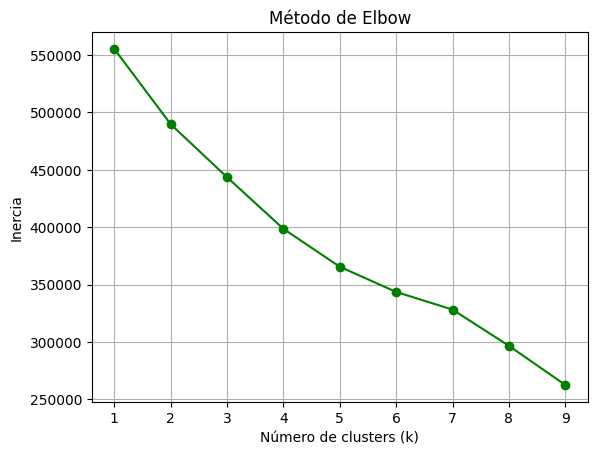

In [60]:
inercia = []
K = range(1, 10)

for k in K:
    modelo = KMeans(n_clusters=k, random_state=42)
    modelo.fit(clim_scal)
    inercia.append(modelo.inertia_)

plt.plot(K, inercia, 'go-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método de Elbow')
plt.grid(True)
plt.show()

Según el Método de Elbow, se identificó que tres agrupamientos representan una estructura óptima de los datos ambientales (ya que la incercia deciende abruptamente entre 1 y 3) logrando un balance entre las caracteristicas de los clusters

In [62]:
for k in range(2, 6):
    modelo = KMeans(n_clusters=k, random_state=42)
    etiquetas = modelo.fit_predict(clim_scal)
    score = silhouette_score(clim_scal, etiquetas)
    print(f"k = {k}, Silhouette Score = {score:.3f}")

k = 2, Silhouette Score = 0.154
k = 3, Silhouette Score = 0.163
k = 4, Silhouette Score = 0.203
k = 5, Silhouette Score = 0.205


El análisis del Silhouette Score sugiere que el modelo con cuatro o cinco clusters logra mayor cohesión interna. Por lo que se procede a utilizar un modelo con 4 clusters para ver los agrupamientos.

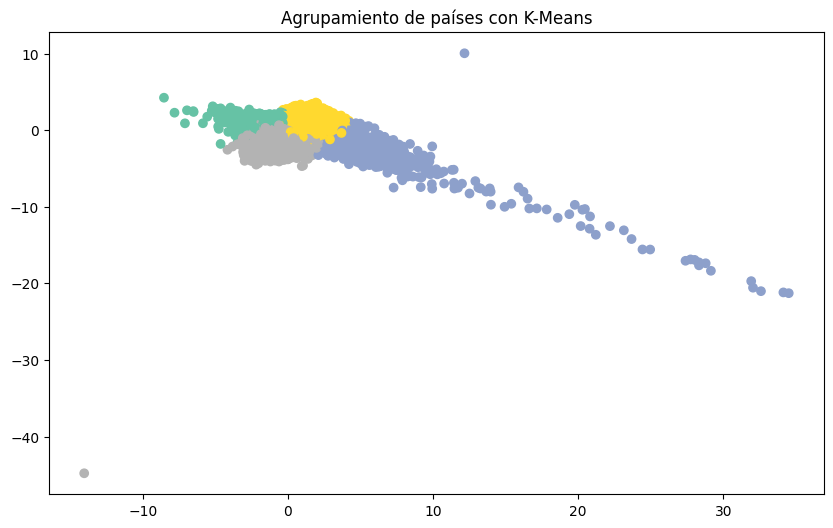

In [67]:
Cmeans = KMeans(n_clusters=4, random_state=42)
clusters = Cmeans.fit_predict(clim_scal)
#Asignamos cada país a un cluster segun los patrones que el algoritmo encuentre
clim_pais_fil['Cluster'] = clusters #Sumamos las columnas de clusters al DF original

#Graficamos los clusters
#PCA es una reducción dimensional que encuentra las componentes principales que captura la mayor varianza en la data.
#PCA toma todas las variables y busca las direcciones que más varían en el conjunto de datos.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(clim_scal) #Acá se aplica PCA al df ya escalado

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='Set2')
plt.title('Agrupamiento de países con K-Means')
#Graficamos los clusters
pca = PCA(n_components=2)
X_pca = pca.fit_transform(clim_scal)

In [70]:
# Agrupamos por cluster y calculamos medias de variables numéricas
resumen_clusters = clim_pais_fil.groupby('Cluster').mean(numeric_only=True)
print(resumen_clusters)

          latitude   longitude  temperature_celsius   wind_mph  pressure_mb  \
Cluster                                                                       
0        -4.431553  133.854933            24.579247   9.167267  1010.954560   
1        17.477560   15.174013            27.593697  15.531008  1013.109244   
2        15.315666   17.473308            28.487624   9.125778  1012.775112   
3        30.796103  -15.359697            15.661658   8.701766  1015.747634   

         precip_mm      cloud  uv_index  air_quality_Carbon_Monoxide  \
Cluster                                                                
0         0.543121  64.915235  1.105469                   229.160249   
1         0.001513   5.617647  5.845126                   340.961134   
2         0.065656  28.781019  7.603884                   274.040007   
3         0.112307  48.211255  1.660763                   320.257904   

         air_quality_PM2.5  air_quality_PM10  dist_to_centroid  
Cluster                    

Al aumentar la cantidad de clusters a cuatro, se logra una segmentación más refinada, permitiendo distinguir entre países tropicales áridos, húmedos, altamente contaminados y de clima templado. Este ajuste mejora la capacidad del modelo para captar patrones en variables ambientales clave.